In [1]:
from PIL import Image
from vangogh.evolution import Evolution
from vangogh.fitness import draw_voronoi_image
from vangogh.util import IMAGE_SHRINK_SCALE, REFERENCE_IMAGE
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from time import time
from mpl_toolkits.axes_grid1 import ImageGrid
plt.style.use('classic')
%matplotlib inline

from multiprocess import Pool, cpu_count

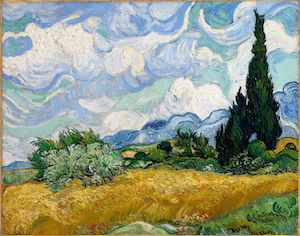

In [2]:
display(REFERENCE_IMAGE)

In [32]:
# Enable to show live rendering of best individual during optimization
display_output = False
# Enable to save progress images at every 50th generation
save_progress = True
# Enable to print verbose output per generation
verbose_output = False

In [33]:
def reporter(time, evo):
    if save_progress or display_output:
        elite = draw_voronoi_image(evo.elite, evo.reference_image.width, evo.reference_image.height, scale=IMAGE_SHRINK_SCALE)
    if display_output:
        clear_output()
        display(elite)
    if save_progress and time["num-generations"] % 50 == 0:
        elite.save(f"./img/van_gogh_intermediate_{evo.seed}_{evo.mutation_schedule}_{evo.initial_mutation_strength}_{evo.final_mutation_strength}_{time['num-generations']:05d}.png")

def run_algorithm(settings):
    seed, mutation_schedule, initial_strength, final_strength = settings
    start = time()
    
    data = []
    evo = Evolution(100,
                    REFERENCE_IMAGE,
                    population_size=100,
                    generation_reporter=reporter,
                    crossover_method="ONE_POINT",
                    seed=seed,
                    initialization="RANDOM",
                    generation_budget=500,
                    mutation_schedule=mutation_schedule,
                    initial_mutation_strength=initial_strength,
                    final_mutation_strength=final_strength,
                    selection_name='tournament_4',
                    verbose=verbose_output)
    data = evo.run()
    time_spent = time() - start
    print(f"Done: seed {seed} - schedule {mutation_schedule} - initial {initial_strength} - final {final_strength} - in {int(time_spent)} seconds")
    
    return data

## Running a single instance

In [31]:
%%time
data = run_algorithm((0, "constant", 0.5, 0.05))

generation: 1 best fitness: 134707 avg. fitness: 143653.01
generation: 2 best fitness: 134273 avg. fitness: 139735.57
generation: 3 best fitness: 132055 avg. fitness: 136514.62
generation: 4 best fitness: 127273 avg. fitness: 134238.04
generation: 5 best fitness: 127273 avg. fitness: 132040.58
generation: 6 best fitness: 122049 avg. fitness: 129646.56
generation: 7 best fitness: 122049 avg. fitness: 127392.55
generation: 8 best fitness: 121902 avg. fitness: 125199.57
generation: 9 best fitness: 121902 avg. fitness: 123498.16
generation: 10 best fitness: 118914 avg. fitness: 122311.44
generation: 11 best fitness: 118914 avg. fitness: 121620.4
generation: 12 best fitness: 116828 avg. fitness: 120624.7
generation: 13 best fitness: 113810 avg. fitness: 119043.54
generation: 14 best fitness: 113740 avg. fitness: 116893.46
generation: 15 best fitness: 113637 avg. fitness: 115296.86
generation: 16 best fitness: 112018 avg. fitness: 114123.08
generation: 17 best fitness: 112018 avg. fitness: 1

## Running a sweep of settings

In [35]:
%%time

mutation_schedules = ["constant", "linear", "exponential", "quadratic"]
initial_strengths = [0.75, 0.5, 0.25]
final_strengths = [0.005]

data = []
for seed in range(1):
    for mutation_schedule in mutation_schedules:
        for initial_strength in initial_strengths:
            if mutation_schedule == "constant":
                final_strength = initial_strength
                final_strength_list = [initial_strength]
            else:
                final_strength_list = final_strengths
            for final_strength in final_strength_list:
                data.extend(run_algorithm((seed, mutation_schedule, initial_strength, final_strength)))

Done: seed 0 - schedule constant - initial 0.75 - final 0.75 - in 145 seconds
Done: seed 0 - schedule constant - initial 0.5 - final 0.5 - in 142 seconds
Done: seed 0 - schedule constant - initial 0.25 - final 0.25 - in 140 seconds
Done: seed 0 - schedule linear - initial 0.75 - final 0.005 - in 142 seconds
Done: seed 0 - schedule linear - initial 0.5 - final 0.005 - in 142 seconds
Done: seed 0 - schedule linear - initial 0.25 - final 0.005 - in 141 seconds
Done: seed 0 - schedule exponential - initial 0.75 - final 0.005 - in 141 seconds
Done: seed 0 - schedule exponential - initial 0.5 - final 0.005 - in 142 seconds
Done: seed 0 - schedule exponential - initial 0.25 - final 0.005 - in 142 seconds
Done: seed 0 - schedule quadratic - initial 0.75 - final 0.005 - in 144 seconds
Done: seed 0 - schedule quadratic - initial 0.5 - final 0.005 - in 144 seconds
Done: seed 0 - schedule quadratic - initial 0.25 - final 0.005 - in 142 seconds
CPU times: user 15min 27s, sys: 2min 43s, total: 18min

## Evaluating the results

In [36]:
df = pd.DataFrame(data)
df["time-elapsed"] = df["time-elapsed"].round(0)

In [37]:
# your plotting code here...

In [38]:
df.head()

,num-generations,num-evaluations,time-elapsed,best-fitness,crossover-method,population-size,num-points,initialization,mutation-schedule,initial-mutation-strength,final-mutation-strength,seed
0,1,200,0.0,134707,ONE_POINT,100,100,RANDOM,constant,0.75,0.75,0
1,2,300,0.0,134273,ONE_POINT,100,100,RANDOM,constant,0.75,0.75,0
2,3,400,1.0,129780,ONE_POINT,100,100,RANDOM,constant,0.75,0.75,0
3,4,500,1.0,127381,ONE_POINT,100,100,RANDOM,constant,0.75,0.75,0
4,5,600,1.0,125709,ONE_POINT,100,100,RANDOM,constant,0.75,0.75,0


In [39]:
summary = df.groupby([
    "mutation-schedule",
    "initial-mutation-strength",
    "final-mutation-strength"
])["best-fitness"].min().reset_index()

summary.sort_values("best-fitness").head(10)

,mutation-schedule,initial-mutation-strength,final-mutation-strength,best-fitness
2,constant,0.75,0.750,39906
1,constant,0.50,0.500,40100
8,linear,0.75,0.005,41274
0,constant,0.25,0.250,45635
7,linear,0.50,0.005,46714
11,quadratic,0.75,0.005,49473
10,quadratic,0.50,0.005,56070
6,linear,0.25,0.005,57939
5,exponential,0.75,0.005,59507
4,exponential,0.50,0.005,64030


## Displaying the best instances over time

In [40]:
def show_progress_over_time(settings, selection=None, grid=(5,4)):
    seed, mutation_schedule, initial_strength, final_strength = settings
    fig = plt.figure(figsize=(20., 20.))
    grid = ImageGrid(fig, 111, 
                     nrows_ncols=grid,
                     axes_pad=0.1,  # pad between axes
                     )

    if selection is None:
        selection = range(50, generation_budget + 50, 50)
    
    img_arr = [Image.open((f"./img/van_gogh_intermediate_{seed}_{mutation_schedule}_{initial_strength}_{final_strength}_{i:05d}.png")) for i in selection]
    for ax, im in zip(grid, img_arr):
        ax.imshow(im)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

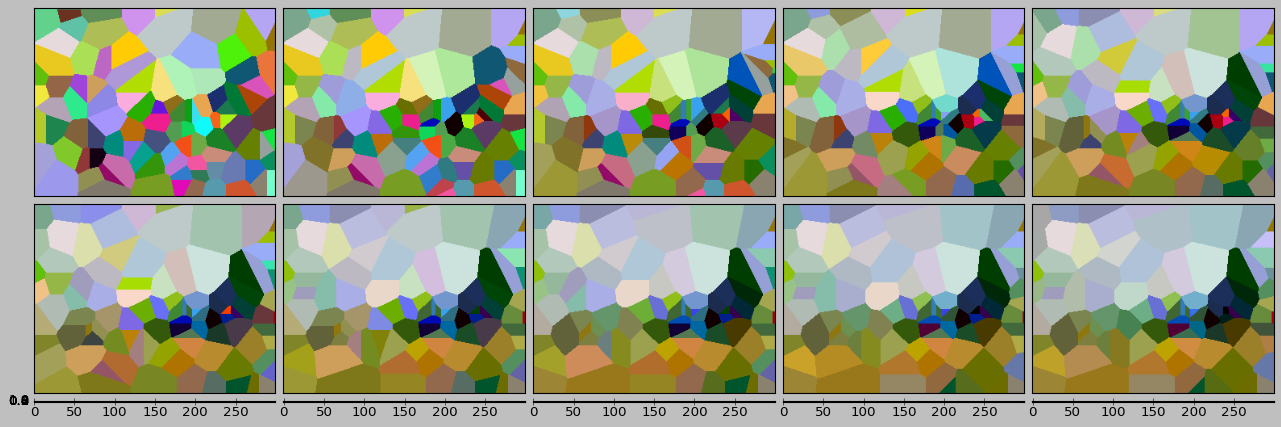

In [44]:
show_progress_over_time((0, "constant", 0.75, 0.75), grid=(3,5))